In [ ]:
MODEL_CLS = "dnmf"
DATASET = "movielens"
STRATEGY = "pointwise"
PATH_WORK_DIR = "../.."

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.chdir(PATH_WORK_DIR)
print(f"DIRECTORY: {os.getcwd()}")

DIRECTORY: c:\Users\jayar\Desktop\바탕 화면\REPO\PAPER REVIEW\RECSYS\02_MLP\05_RS-DNCF


In [4]:
import sys
sys.path.append("src")

# Config

In [5]:
import pandas as pd
from recsys import config, pipeline, trainer, evaluator, utils
import dncf

In [ ]:
PATH = f"./config/{DATASET}/{MODEL_CLS}_{STRATEGY}.yaml"
cfg = config.builder.config_builder(PATH)

In [7]:
utils.seed.main(cfg.seed)

ALL SEEDS RESET: 42


# Data Preparation

In [8]:
PATH = f"./data/{cfg.dataset}.csv"
df = pd.read_csv(PATH)

In [10]:
kwargs = dict(
    df=df,
    cfg=cfg.pipeline,
)

dataloaders, interactions, histories = pipeline.builder.pipeline_builder(**kwargs)

# Modeling

In [11]:
kwargs = dict(
    interactions=interactions,
    num_users=cfg.model.dgmf.num_users,
    num_items=cfg.model.dgmf.num_items,
    **cfg.model.dgmf.params,
)

dgmf = dncf.dgmf.Module(**kwargs)

In [12]:
kwargs = dict(
    interactions=interactions,
    num_users=cfg.model.dmlp.num_users,
    num_items=cfg.model.dmlp.num_items,
    **cfg.model.dmlp.params,
)

dmlp = dncf.dmlp.Module(**kwargs)

In [13]:
kwargs = dict(
    dgmf=dgmf,
    dmlp=dmlp,
)    

model = dncf.dnmf.Module(**kwargs)

# Train

In [14]:
kwargs = dict(
    model=model,
    cfg=cfg.trainer,
)

trainer = trainer.builder.trainer_builder(**kwargs)

In [15]:
kwargs = dict(
    trn_loader=dataloaders["trn"],
    val_loader=dataloaders["val"],
)

records = trainer.fit(**kwargs)

VALIDATION
	BEST SCORE: 0.5738
	BEST EPOCH: 24


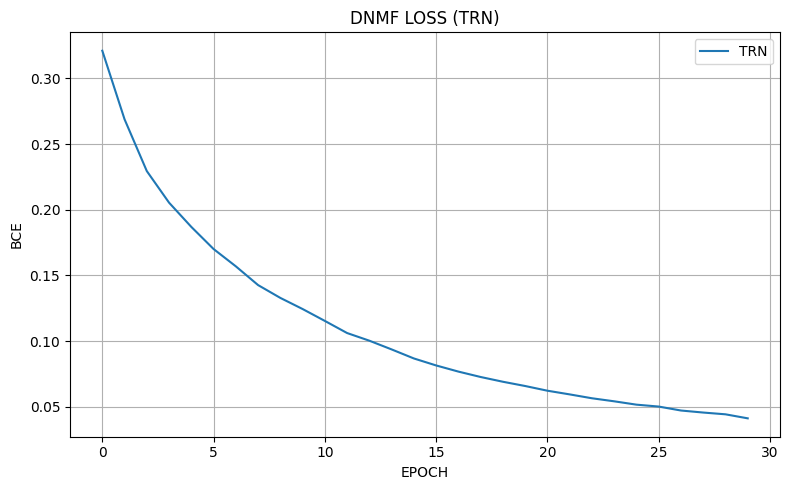

In [16]:
kwargs = dict(
    record=records["trn"],
    label="TRN",
    criterion="BCE",
    title="DNMF LOSS (TRN)",
)

utils.visualizer.main(**kwargs)

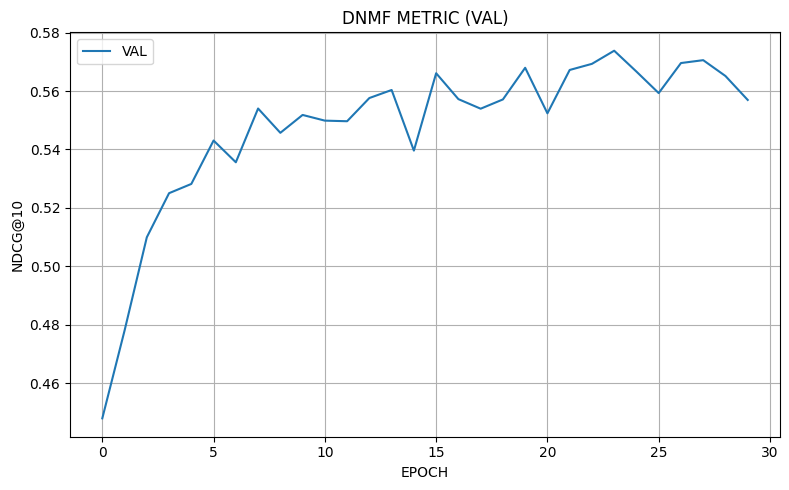

In [17]:
kwargs = dict(
    record=records["val"],
    label="VAL",
    criterion="NDCG@10",
    title="DNMF METRIC (VAL)",
)

utils.visualizer.main(**kwargs)

# Test

In [18]:
kwargs = dict(
    model=model,
    cfg=cfg.evaluator,
)

evaluator = evaluator.builder.evaluator_builder(**kwargs)

In [19]:
result, metrics_sheet = evaluator(dataloaders["tst"])

TST: 100%|██████████| 3195/3195 [00:11<00:00, 277.63it/s]


In [20]:
metrics_sheet

,k,hit_ratio,precision,recall,map,ndcg
0,5,0.919408,0.457566,0.386133,0.307565,0.569530
1,10,0.962171,0.343750,0.503307,0.361606,0.573776
2,15,0.975329,0.280702,0.576532,0.385238,0.582963
3,20,0.985197,0.241530,0.620536,0.398595,0.590988
4,25,0.988487,0.212566,0.657235,0.408045,0.598378
5,50,0.996711,0.134671,0.746427,0.426965,0.619024


# Save

In [21]:
PATH = f'./checkpoints/{cfg.dataset}/{cfg.model_cls}_{cfg.strategy}.pth'

kwargs = dict(
    obj=model,
    path=PATH,
)

utils.checkpointer.save(**kwargs)